# Motif-syntax knockout across three activity classes

For each class (**activating / neutral / repressing**) one cell + one figure showing **WT activity** vs the
**motif-syntax KO** activity (annotated motifs replaced by dinucleotide-shuffled background, 20 reps).

WT seqs and motif annotations come from the **same single source as `swap_experiment.ipynb`**:
`situate/edits.csv`, keyed `SEAM:K562:{name}:foreground_scaled` (variable-region coords `[0,200)`).
Run with the Hippo venv kernel (has the K562 encoder + tangermeme + CUDA).

In [1]:
# setup: K562 encoder, WT sources, situate annotations, and the KO / plotting helpers.
import sys
# force the SEAM/Hippo build of the encoder (matches the K562 ckpt's HeadConfig)
sys.path.insert(0, "/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/"
                   "Hippo_dependency_chromatin-accessibility/alphagenome-encoder-ft/src")
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from pathlib import Path
from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import dinucleotide_shuffle
from alphagenome_encoder_ft import EncoderMPRAModel

ADAPTER = 15       # annotation coords are insert[15:215]; offset into the 230bp insert
N_SHUF  = 20       # dinuc-shuffle replicates per KO

# ---- K562 encoder + scoring (same ckpt/suffix as swap_experiment) ----
CKPT = "/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt"
model = EncoderMPRAModel.from_checkpoint(CKPT, device="cuda").eval()
cfg = torch.load(CKPT, map_location="cpu", weights_only=False)["construct_config"]
suffix = one_hot_encode(cfg["promoter_seq"] + cfg["barcode_seq"]).float()   # (4,51) promoter+barcode

@torch.no_grad()
def predict_k562(ohe):                                # (B,4,230) -> (B,) K562 pred
    out = []
    for k in range(0, len(ohe), 512):
        b = ohe[k:k + 512]
        x = torch.cat([b, suffix.expand(len(b), -1, -1)], 2)   # (b,4,281)
        out.append(model(x.transpose(1, 2).cuda()).cpu().numpy())
    return np.concatenate(out)

# ---- WT sequence sources (one per class, as in swap_experiment) ----
FG   = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/foregrounds")
_mp  = pd.read_csv("/grid/koo/home/pmantill/projects/SEAM_validate/data/mpra/K562_averaged.tsv", sep="\t")
seqmap = dict(zip(_mp.seq_id.astype(str).str.rstrip(":"), _mp.seq))          # peak / neutral WT (230bp insert)
libj = pd.read_pickle("/grid/koo/home/pmantill/projects/Virtual_Experiments/MoConSwap_mpra/"
                      "SEAM_jointlib900/libraries/jointlib900_library.pkl")["df"]
libj = libj[libj.cell_type == "K562"].set_index("seq_idx")                   # repressing rep WT (jointlib)

# ---- motif annotations: SINGLE source = situate/edits.csv (var-region coords [0,200)) ----
sit = pd.read_csv("/grid/koo/home/pmantill/projects/situate/edits.csv")
spans = {k: list(zip(g.start.astype(int), g.end.astype(int))) for k, g in sit.groupby("sequence_name")}
def regions_of(name):                                 # annotated motif spans for a foreground ([] if none)
    return spans.get(f"SEAM:K562:{name}:foreground_scaled", [])

# ---- build the three classes from the single_seq foregrounds (10 each) ----
def wt_activating(n): return seqmap[n.rstrip(":")]
def wt_neutral(n):    return seqmap[n[len("neutral_"):].rstrip(":")]
def wt_repressing(n): return libj.loc[int(n[len("rep_"):]), "sequence"]

def collect(keep, wt_fn):                             # {name: (wt_str, regions)} for foregrounds passing `keep`
    names = sorted(d.name for d in FG.iterdir() if keep(d.name))
    return {n: (wt_fn(n), regions_of(n)) for n in names}

CLASSES = {
    "activating": collect(lambda n: not n.startswith(("rep_", "neutral_")), wt_activating),  # bare peak/ENSG
    "neutral":    collect(lambda n: n.startswith("neutral_"),              wt_neutral),
    "repressing": collect(lambda n: n.startswith("rep_"),                  wt_repressing),
}
for cls, d in CLASSES.items():
    print(f"{cls:11s}: {len(d):2d} seqs, {sum(bool(r) for _, r in d.values())} annotated in situate")

# ---- KO + plotting helpers ----
def run_ko(seqs):                                     # {name:(wt_str,regions)} -> wt_pred{}, ko_pred{}
    wt_pred, ko_pred = {}, {}
    for name, (wt_str, regions) in seqs.items():
        wt = one_hot_encode(wt_str).float()                                     # (4,230)
        shuf = dinucleotide_shuffle(wt.unsqueeze(0), n=N_SHUF, random_state=0)[0]  # (20,4,230)
        chim = wt.unsqueeze(0).repeat(N_SHUF, 1, 1).clone()
        for s, e in regions:                                                    # knock out every annotated motif
            chim[:, :, s + ADAPTER:e + ADAPTER] = shuf[:, :, s + ADAPTER:e + ADAPTER]
        wt_pred[name] = float(predict_k562(wt.unsqueeze(0))[0])                  # one WT value per seq
        ko_pred[name] = predict_k562(chim)                                      # (20,) one per shuffle rep
    return wt_pred, ko_pred

FIGS = Path("/grid/koo/home/pmantill/projects/SEAM_validate/mcs_k562/figure_scripts/figs")
def plot_wt_ko(wt_pred, ko_pred, title, target=None, save=None):
    names = list(wt_pred); x = np.arange(len(names)); w = 0.35
    fig, ax = plt.subplots(figsize=(max(9, 1.1 * len(names)), 5))
    ax.scatter(x - w / 2, [wt_pred[n] for n in names], marker="_", s=600,
               color="#4c72b0", linewidths=2, zorder=3)                          # WT = blue dash
    b = ax.boxplot([ko_pred[n] for n in names], positions=x + w / 2, widths=w,
                   patch_artist=True, showfliers=False)                          # KO = red box over 20 reps
    for box in b["boxes"]: box.set_facecolor("#c44e52")
    if target is not None: ax.axhline(target, color="0.6", lw=0.8, ls="--")
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_ylabel("K562 pred_koo"); ax.set_title(title)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)   # despine top/right
    ax.legend([plt.Line2D([], [], color="#4c72b0", lw=2), b["boxes"][0]],
              ["WT", "motif-syntax KO (dinuc, 20 reps)"],
              loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)        # legend outside the axes
    plt.tight_layout()
    if save:
        FIGS.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGS / save, dpi=150, bbox_inches="tight"); print("wrote", FIGS / save)

activating : 10 seqs, 8 annotated in situate
neutral    : 10 seqs, 10 annotated in situate
repressing : 10 seqs, 10 annotated in situate


wrote /grid/koo/home/pmantill/projects/SEAM_validate/mcs_k562/figure_scripts/figs/ko_activating.png


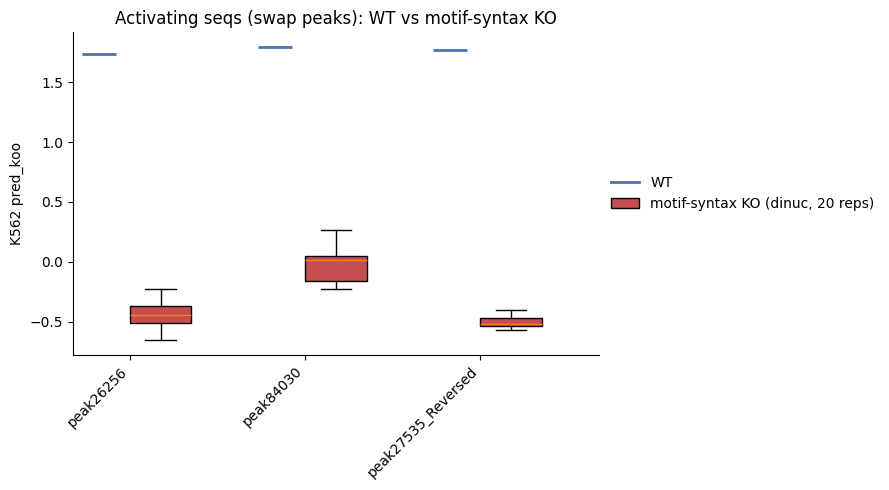

In [2]:
# ACTIVATING: WT (high K562 activity) vs motif-syntax KO. Knocking out the motifs should collapse activity.
# EXACTLY as swap_experiment: the 3 designed peaks, WT from mutagenesis_lib h5 wt_seq_str (the sequence the
# situate annotations are aligned to), NOT seqmap. Spans from situate/edits.csv via regions_of.
import h5py
LIB = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/mutagenesis_lib")
swap3 = ["peak26256", "peak84030", "peak27535_Reversed"]
def wt_mutlib(peak):
    with h5py.File(LIB / f"{peak}.h5") as f:
        s = f.attrs["wt_seq_str"]
    return s.decode() if isinstance(s, bytes) else s
act3 = {n: (wt_mutlib(n), regions_of(n)) for n in swap3}    # {name: (wt_str, regions)}, same WT as swap_experiment
wt_pred, ko_pred = run_ko(act3)
plot_wt_ko(wt_pred, ko_pred, "Activating seqs (swap peaks): WT vs motif-syntax KO", save="ko_activating.png")

wrote /grid/koo/home/pmantill/projects/SEAM_validate/mcs_k562/figure_scripts/figs/ko_neutral.png


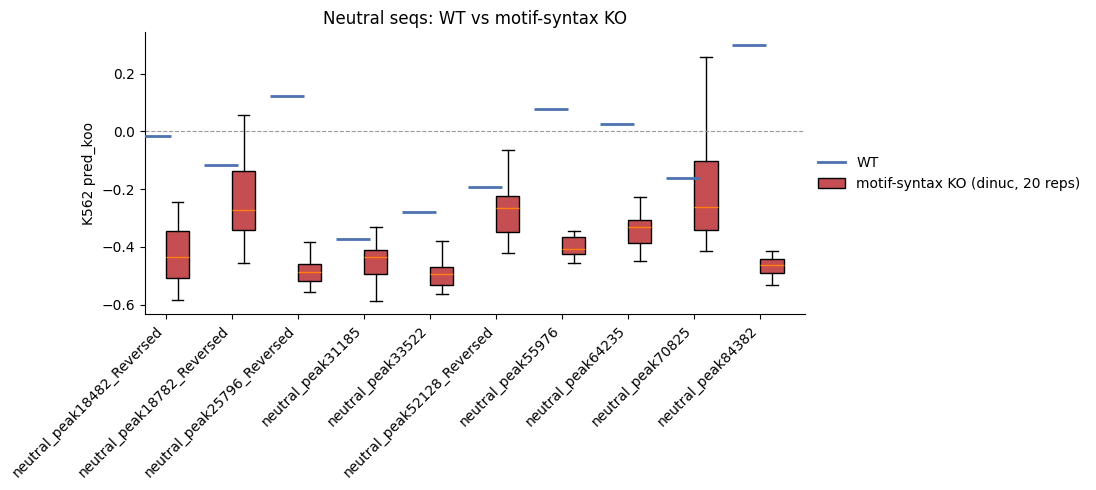

In [3]:
# NEUTRAL: WT activity ~ 0 (dashed line) vs motif-syntax KO. Little to lose, so KO should stay near baseline.
wt_pred, ko_pred = run_ko(CLASSES["neutral"])
plot_wt_ko(wt_pred, ko_pred, "Neutral seqs: WT vs motif-syntax KO", target=0.0, save="ko_neutral.png")

wrote /grid/koo/home/pmantill/projects/SEAM_validate/mcs_k562/figure_scripts/figs/ko_repressing.png


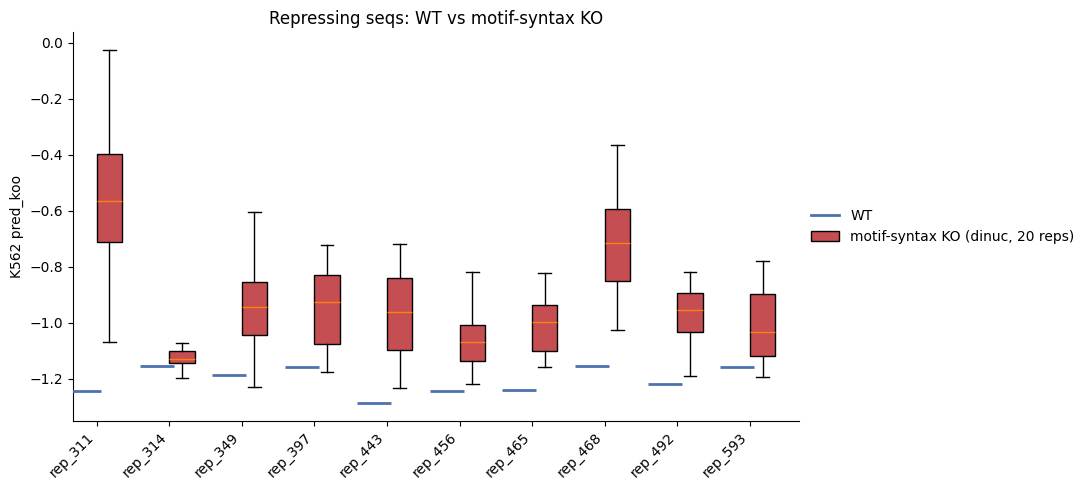

In [4]:
# REPRESSING: WT (low/negative K562 activity) vs motif-syntax KO. Knocking out repressive motifs should raise activity.
wt_pred, ko_pred = run_ko(CLASSES["repressing"])
plot_wt_ko(wt_pred, ko_pred, "Repressing seqs: WT vs motif-syntax KO", save="ko_repressing.png")

wrote /grid/koo/home/pmantill/projects/SEAM_validate/mcs_k562/figure_scripts/figs/peak84030_wt_vs_ko_ism.png


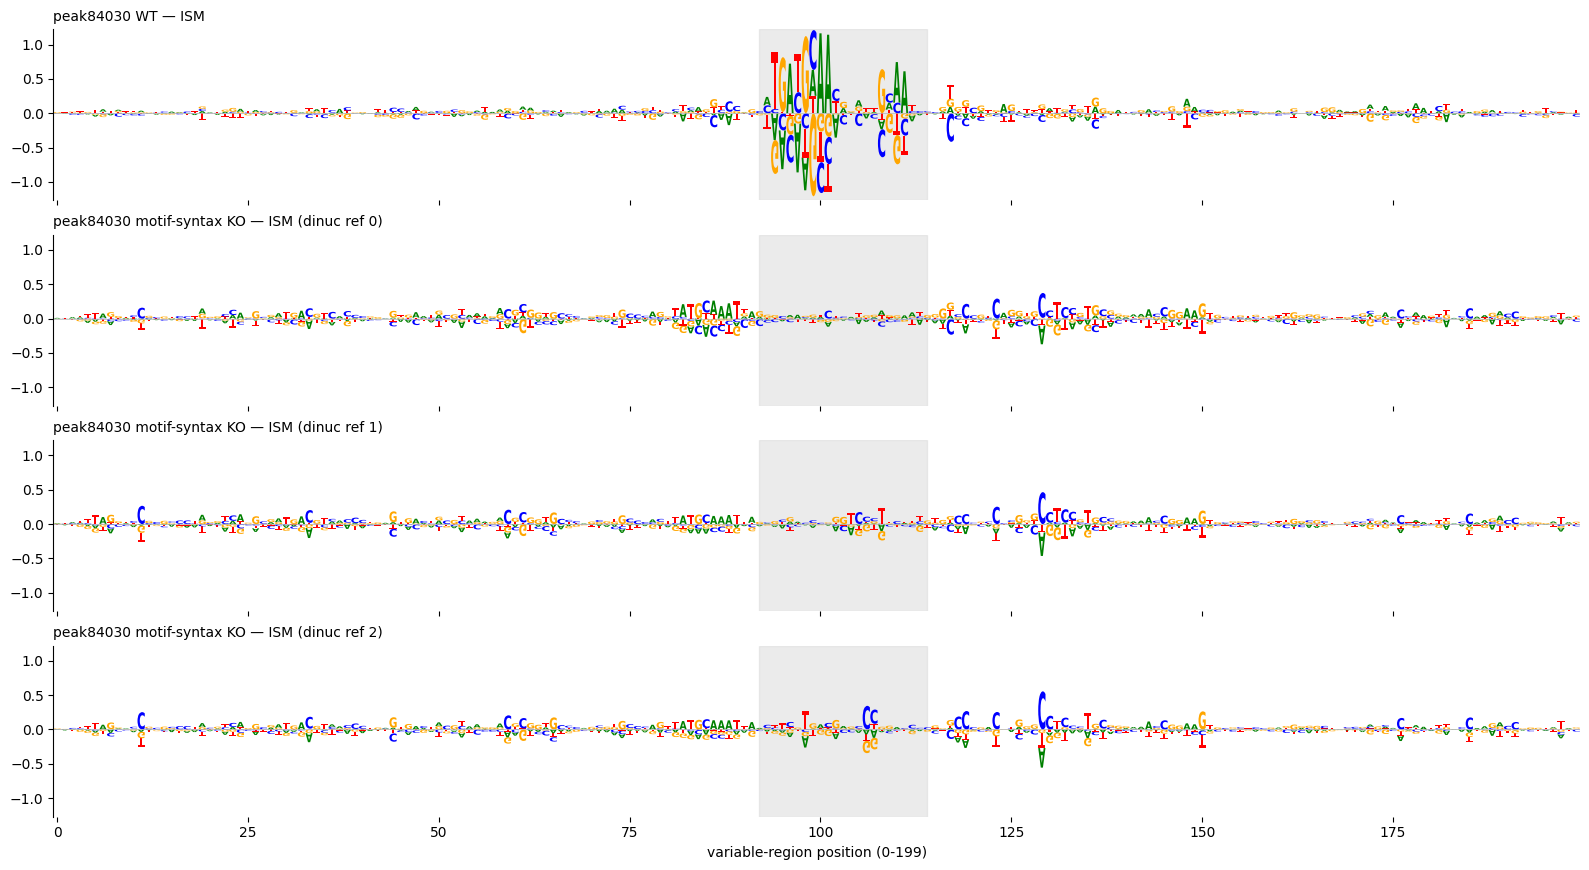

In [5]:
# peak84030: WT ISM logo vs motif-syntax-KO ISM logos for 3 dinuc-shuffle refs.
# simple ISM: at each var-region position score all 4 single-base muts, zero at the WT base, mean-center channels.
# KO refs are deterministic (dinucleotide_shuffle is seeded); reps 0/1/2 are 3 distinct shuffle realizations.
sys.path.insert(0, "/grid/koo/home/pmantill/projects/EigenMaps/eigen-interactions")
from fast_logo import fast_logo

BASES = np.array(list("ACGT"))

@torch.no_grad()
def ism_map(seq_str):                                   # 230bp str -> (200,4) ISM over the variable region
    seq = one_hot_encode(seq_str).float()               # (4,230)
    block = seq.unsqueeze(0).repeat(800, 1, 1).clone()  # 200 positions x 4 bases
    for j, p in enumerate(range(ADAPTER, ADAPTER + 200)):
        block[j * 4:j * 4 + 4, :, p] = torch.eye(4)     # the 4 single-base mutants at p
    m = predict_k562(block).reshape(200, 4)             # (200,4) raw pred per mutant
    wt_base = seq[:, ADAPTER:ADAPTER + 200].numpy().T.argmax(1)   # (200,) WT base index per position
    m = m - m[np.arange(200), wt_base][:, None]         # zero at the WT base
    m = m - m.mean(1, keepdims=True)                    # mean-center across channels (hypothetical)
    return m

# WT (mutagenesis_lib wt_seq_str, same as swap_experiment) and 3 motif-syntax KO refs (annotated motifs -> dinuc bg).
N_REFS  = 3
wt_str  = wt_mutlib("peak84030")
regions = regions_of("peak84030")
wt      = one_hot_encode(wt_str).float()
shuf    = dinucleotide_shuffle(wt.unsqueeze(0), n=N_SHUF, random_state=0)[0]   # (20,4,230), seeded -> reproducible
ko_strs = []
for r in range(N_REFS):                                 # 3 distinct KO realizations (shuffle reps 0,1,2)
    ko = wt.clone()
    for s, e in regions:
        ko[:, s + ADAPTER:e + ADAPTER] = shuf[r, :, s + ADAPTER:e + ADAPTER]
    ko_strs.append("".join(BASES[ko.argmax(0).numpy()]))

maps  = [("peak84030 WT — ISM", ism_map(wt_str))]
maps += [(f"peak84030 motif-syntax KO — ISM (dinuc ref {r})", ism_map(s)) for r, s in enumerate(ko_strs)]
lo = min(m.min() for _, m in maps) * 1.05
hi = max(m.max() for _, m in maps) * 1.05
ylim = (lo, hi)

fig, axes = plt.subplots(len(maps), 1, figsize=(16, 2.2 * len(maps)), sharex=True)
for ax, (ttl, vals) in zip(axes, maps):
    fast_logo(vals, ax, ylim=ylim)                      # full (L,4) ACGT, all channels
    for s, e in regions:                                # shade the annotated (knocked-out) motif spans
        ax.axvspan(s, e, color="0.85", alpha=0.5, zorder=0)
    ax.axhline(0, color="0.7", lw=0.5)
    ax.set_title(ttl, loc="left", fontsize=10)
    for sp in ("top", "right", "bottom"):
        ax.spines[sp].set_visible(False)
axes[-1].set_xlabel("variable-region position (0-199)")
fig.tight_layout()
FIGS.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGS / "peak84030_wt_vs_ko_ism.png", dpi=300, bbox_inches="tight")
print("wrote", FIGS / "peak84030_wt_vs_ko_ism.png")

In [6]:
# WT vs motif KO vs context KO, as box plots (one figure per activity class).
# motif KO   : annotated motif spans -> dinuc bg, context kept   (as run_ko).
# context KO : the MIRROR -- keep the annotated motifs, dinuc-shuffle the rest of the variable region.
# Each sequence contributes ONE value per group (KO = mean over the N_SHUF shuffle reps), so all three
# boxes have n = #seqs and reflect seq-to-seq spread, directly comparable to WT.
def run_both_ko(seqs):                                   # {name:(wt_str,regions)} -> wt{}, motif_ko{}, ctx_ko{}
    wt_v, mko_v, cko_v = {}, {}, {}
    for name, (wt_str, regions) in seqs.items():
        wt   = one_hot_encode(wt_str).float()                                       # (4,230)
        shuf = dinucleotide_shuffle(wt.unsqueeze(0), n=N_SHUF, random_state=0)[0]    # (20,4,230), seeded
        mko  = wt.unsqueeze(0).repeat(N_SHUF, 1, 1).clone()
        cko  = wt.unsqueeze(0).repeat(N_SHUF, 1, 1).clone()
        ctx  = np.ones(200, bool)                                                    # var-region [0,200) context mask
        for s, e in regions:
            mko[:, :, s + ADAPTER:e + ADAPTER] = shuf[:, :, s + ADAPTER:e + ADAPTER] # motif KO: shuffle the motifs
            ctx[s:e] = False                                                         # motifs are NOT context
        cpos = ADAPTER + np.where(ctx)[0]                                            # context positions in the insert
        cko[:, :, cpos] = shuf[:, :, cpos]                                           # context KO: shuffle everything else
        wt_v[name]  = float(predict_k562(wt.unsqueeze(0))[0])
        mko_v[name] = float(predict_k562(mko).mean())                               # mean over 20 reps
        cko_v[name] = float(predict_k562(cko).mean())
    return wt_v, mko_v, cko_v

_JIT = np.random.default_rng(0)
def plot_box(wt_v, mko_v, cko_v, title, save=None):
    names = list(wt_v)
    data   = [[wt_v[n] for n in names], [mko_v[n] for n in names], [cko_v[n] for n in names]]
    labels = ["WT", "motif KO", "context KO"]
    colors = ["#4c72b0", "#c44e52", "#55a868"]
    fig, ax = plt.subplots(figsize=(4.5, 5))
    b = ax.boxplot(data, widths=0.6, patch_artist=True, showfliers=False)
    for box, c in zip(b["boxes"], colors): box.set_facecolor(c); box.set_alpha(0.75)
    for med in b["medians"]: med.set_color("0.15")
    for i, d in enumerate(data):                                                     # overlay per-seq points
        ax.scatter(np.full(len(d), i + 1) + _JIT.uniform(-0.08, 0.08, len(d)),
                   d, color="0.2", s=14, zorder=3)
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(labels)
    ax.set_ylabel("K562 pred_koo"); ax.set_title(title)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    if save:
        FIGS.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGS / save, dpi=150, bbox_inches="tight"); print("wrote", FIGS / save)

wrote /grid/koo/home/pmantill/projects/SEAM_validate/mcs_k562/figure_scripts/figs/box_activating.png


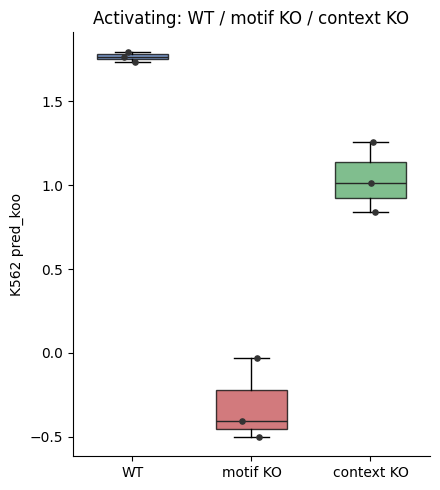

In [7]:
# ACTIVATING: WT vs motif KO vs context KO (swap peaks, same WT as swap_experiment via act3).
wt_v, mko_v, cko_v = run_both_ko(act3)
plot_box(wt_v, mko_v, cko_v, "Activating: WT / motif KO / context KO", save="box_activating.png")

wrote /grid/koo/home/pmantill/projects/SEAM_validate/mcs_k562/figure_scripts/figs/box_neutral.png


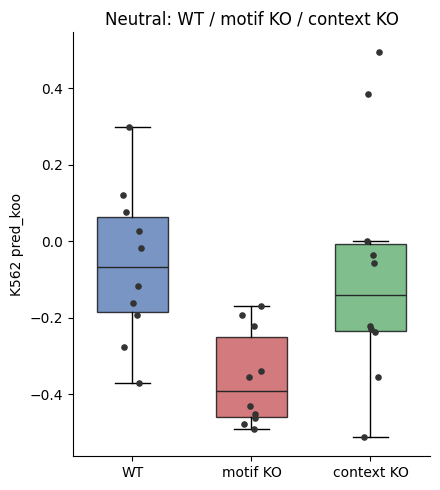

In [8]:
# NEUTRAL: WT vs motif KO vs context KO.
wt_v, mko_v, cko_v = run_both_ko(CLASSES["neutral"])
plot_box(wt_v, mko_v, cko_v, "Neutral: WT / motif KO / context KO", save="box_neutral.png")

wrote /grid/koo/home/pmantill/projects/SEAM_validate/mcs_k562/figure_scripts/figs/box_repressing.png


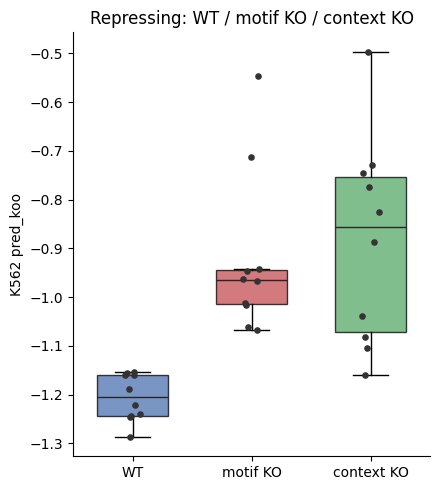

In [9]:
# REPRESSING: WT vs motif KO vs context KO.
wt_v, mko_v, cko_v = run_both_ko(CLASSES["repressing"])
plot_box(wt_v, mko_v, cko_v, "Repressing: WT / motif KO / context KO", save="box_repressing.png")